**upload csv dataset**

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving student_performance.csv to student_performance.csv


**Read the CSV Dataset**

In [ ]:
import pandas as pd

data = pd.read_csv("student_performance.csv")
data

,study_hours,attendance,assignments,previous_marks,result
0,5,80,7,65,Pass
1,2,50,3,40,Fail
2,4,70,6,60,Pass
3,3,60,5,50,NaN
4,6,85,8,75,Pass
5,1,40,2,35,Fail
6,4,75,6,62,NaN
7,5,90,7,70,Pass
8,2,55,4,45,Fail
9,3,65,5,55,NaN


**Convert Pass/Fail to Numbers**

In [ ]:
data['result'] = data['result'].replace({'Pass':1,'Fail':0})
data

/tmp/ipykernel_180/235528327.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['result'] = data['result'].replace({'Pass':1,'Fail':0})


,study_hours,attendance,assignments,previous_marks,result
0,5,80,7,65,1.0
1,2,50,3,40,0.0
2,4,70,6,60,1.0
3,3,60,5,50,NaN
4,6,85,8,75,1.0
5,1,40,2,35,0.0
6,4,75,6,62,NaN
7,5,90,7,70,1.0
8,2,55,4,45,0.0
9,3,65,5,55,NaN


**Output After Separating Labeled Data and unlabeled Data**

In [ ]:
labeled = data[data['result'].notna()]
unlabeled = data[data['result'].isna()]

print("Labeled Data")
print(labeled)

print("\nUnlabeled Data")
print(unlabeled)

Labeled Data
   study_hours  attendance  assignments  previous_marks  result
0            5          80            7              65     1.0
1            2          50            3              40     0.0
2            4          70            6              60     1.0
4            6          85            8              75     1.0
5            1          40            2              35     0.0
7            5          90            7              70     1.0
8            2          55            4              45     0.0

Unlabeled Data
   study_hours  attendance  assignments  previous_marks  result
3            3          60            5              50     NaN
6            4          75            6              62     NaN
9            3          65            5              55     NaN


**Define Features and Target**

In [ ]:
X = labeled[['study_hours','attendance','assignments','previous_marks']]
y = labeled['result']

**Import Self-Training Model**

In [ ]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = SelfTrainingClassifier(DecisionTreeClassifier())
model.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_self_training.py:288: UserWarning: y contains no unlabeled samples
  warnings.warn("y contains no unlabeled samples", UserWarning)


SelfTrainingClassifier(estimator=DecisionTreeClassifier())

In [ ]:
X_unlabeled = unlabeled[['study_hours','attendance','assignments','previous_marks']]

predictions = model.predict(X_unlabeled)

print("Predicted Results:", predictions)

Predicted Results: [0. 1. 0.]


In [ ]:
unlabeled.loc[:, 'result'] = predictions

final_data = pd.concat([labeled,unlabeled])

print(final_data)

   study_hours  attendance  assignments  previous_marks  result
0            5          80            7              65     1.0
1            2          50            3              40     0.0
2            4          70            6              60     1.0
4            6          85            8              75     1.0
5            1          40            2              35     0.0
7            5          90            7              70     1.0
8            2          55            4              45     0.0
3            3          60            5              50     0.0
6            4          75            6              62     1.0
9            3          65            5              55     0.0


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 1.0


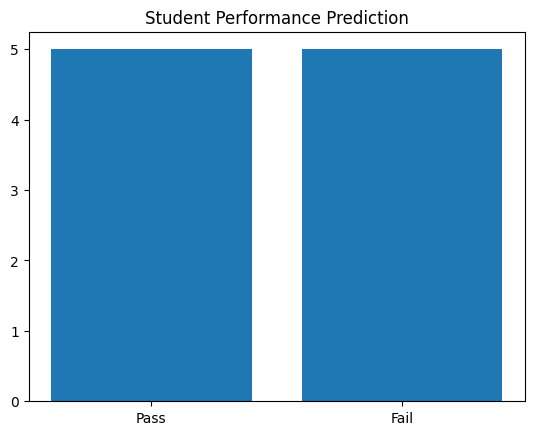

In [ ]:
import matplotlib.pyplot as plt

counts = final_data['result'].value_counts()

plt.bar(['Pass','Fail'],counts)
plt.title("Student Performance Prediction")
plt.show()

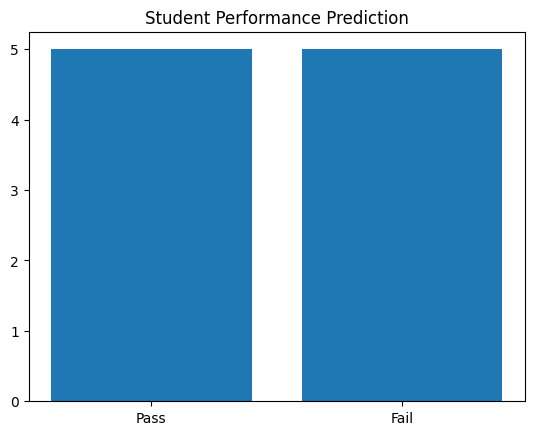

In [ ]:
import matplotlib.pyplot as plt

counts = final_data['result'].value_counts()

plt.bar(['Pass','Fail'],counts)
plt.title("Student Performance Prediction")
plt.show()